# Pneumonia Classifier using CNN (PyTorch)

## Importing Essential Packages

In [ ]:
from pathlib import Path
from collections import Counter

import random
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve

import torch
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torchvision import transforms
from torchvision.datasets import ImageFolder

import torch.nn as nn 
import torch.optim as optim


## Configuration

In [2]:
SEED = 67

IMG_SIZE = 224
BATCH_SIZE = 32

TRAIN_DIR = "../data/train"
# VAL_DIR = "..."
TEST_DIR = '../data/test'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Loading Raw Dataset

### Creating Custom Dataset Class 

In [3]:
# Custom Dataset
class PneumoniaDataset(Dataset):

    VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}

    def __init__(self, root_dir, transform = None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        self.class_map = {"NORMAL": 0, "PNEUMONIA": 1}

        for class_name, label in self.class_map.items():
            class_path = self.root_dir / class_name

            if not class_path.exists(): # Checking If the required directory exists or not
                raise FileNotFoundError(f"Missing Directory {class_path}")
            
            for img_path in sorted(class_path.iterdir()):

                if img_path.suffix.lower() not in self.VALID_EXTENSIONS: # verifying if images are with valid extensions
                    continue

                try:
                    with Image.open(img_path) as img: # for skipping corruped image
                        img.verify()

                    self.samples.append((img_path, label))
                
                except Exception:
                    print(f"Skipping Corrupted Image: {img_path}")

        if not self.samples:
            raise RuntimeError(f"No valid images found in {self.root_dir}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, index):
        if index >= len(self.samples):
            raise IndexError("Index outta Bound")
        image_path, label = self.samples[index]
        with Image.open(image_path) as img:
            image = img.convert("L")

        if self.transform:
            image = self.transform(image) 

        return image, label           

### Loading Raw Dataset

In [4]:
full_train_dataset = PneumoniaDataset(TRAIN_DIR)

print("Total Images (Samples): ", full_train_dataset.__len__())

Total Images (Samples):  5216


## Exploratory Data Analysis (EDA)

### Class Distribution

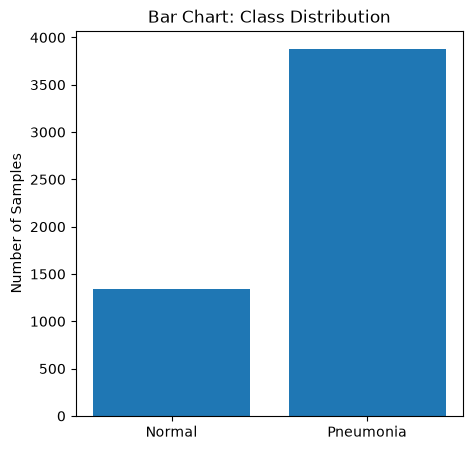

In [5]:
full_train_labels = [label for _, label in full_train_dataset.samples]

class_counts = Counter(full_train_labels)

plt.figure(figsize = (5, 5))

plt.title("Bar Chart: Class Distribution")

plt.bar(["Normal", "Pneumonia"], class_counts.values())
plt.ylabel("Number of Samples")

plt.show()

### Visualizing Random Samples

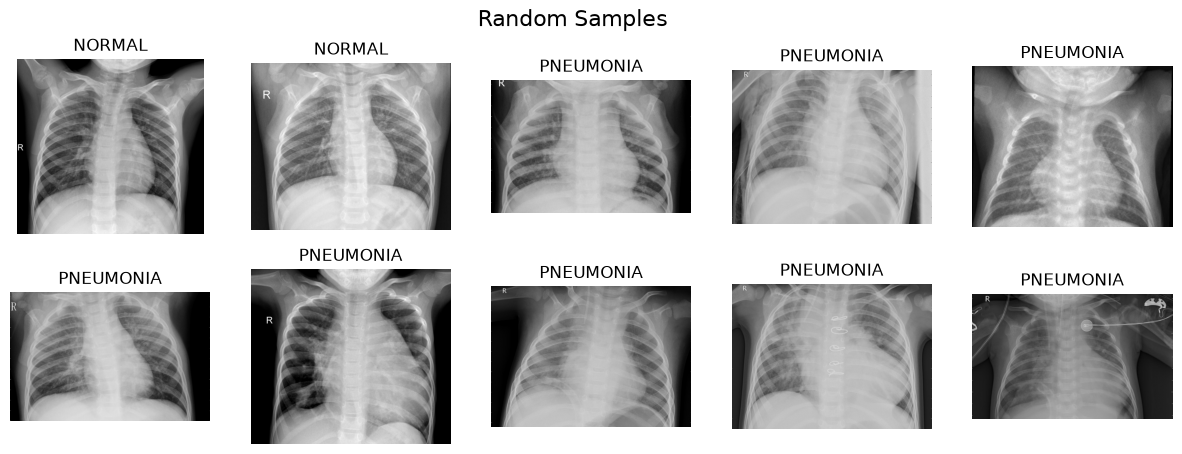

In [6]:
fig, axes = plt.subplots(2, 5, figsize = (15, 5))

randomSamples = random.sample(range(len(full_train_dataset)), 10)
flattenedAxes = axes.flatten()
pairedSampleAxe = zip(flattenedAxes, randomSamples)

for ax, randomIndex in pairedSampleAxe:
    img, label = full_train_dataset.__getitem__(randomIndex)
    ax.set_title(f"{"NORMAL" if label == 0 else "PNEUMONIA"}")
    ax.imshow(img, cmap="gray")
    ax.axis("off")

fig.suptitle("Random Samples", fontsize = 16)
plt.show()



### Image Size Analysis

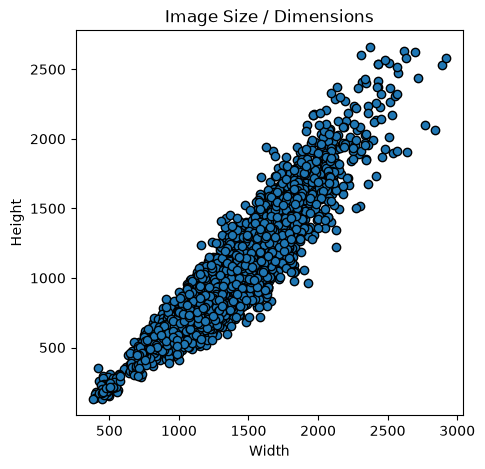

In [7]:
sizes = []

for path, _ in full_train_dataset.samples:

    with Image.open(path) as img:
        sizes.append(img.size)

widths = [x[0] for x in sizes]
heights = [x[1] for x in sizes]

plt.figure(figsize=(5, 5))
plt.title("Image Size / Dimensions")

plt.scatter(widths, heights, edgecolor = "#000")
plt.xlabel("Width")
plt.ylabel("Height")
plt.axis("equal")

plt.show()

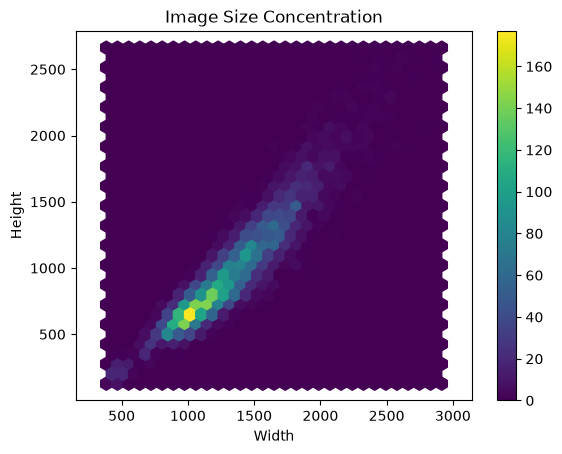

In [8]:
plt.title("Image Size Concentration")

plt.hexbin(widths, heights, gridsize = 30)
plt.colorbar()
plt.xlabel("Width")
plt.ylabel("Height")
plt.axis("equal")

plt.show()

## Data Preprocessing and Loading

### Train Validation Indices Split

In [9]:
full_train_labels = [label for _, label in full_train_dataset.samples]

indices = list(range(full_train_dataset.__len__()))

train_idx, val_idx = train_test_split(
    indices,
    test_size = 0.2,
    random_state = 67,
    stratify = full_train_labels
)

### Transformations

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

other_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

### Dataset Creation

In [11]:
train_dataset = Subset(
    PneumoniaDataset(TRAIN_DIR, transform = train_transform),
    train_idx
)

val_dataset = Subset(
    PneumoniaDataset(TRAIN_DIR, transform = other_transform),
    val_idx
)

test_dataset = PneumoniaDataset(TEST_DIR, transform = other_transform)

In [12]:
# Without Custom Dataset
"""
train_dataset = ImageFolder(
    root = TRAIN_DIR,
    transform = transform
)
val_dataset = ImageFolder(
    root = TRAIN_DIR,
    transform = transform
)
test_dataset = ImageFolder(
    root = TEST_DIR,
    transform = transform
)

"""

'\ntrain_dataset = ImageFolder(\n    root = TRAIN_DIR,\n    transform = transform\n)\nval_dataset = ImageFolder(\n    root = TRAIN_DIR,\n    transform = transform\n)\ntest_dataset = ImageFolder(\n    root = TEST_DIR,\n    transform = transform\n)\n\n'

### Handling Class Imbalance

In [13]:
class_counts = Counter(full_train_labels)

num_samples = len(full_train_labels)

class_weights = {
    cls: num_samples / count for cls, count in class_counts.items()
}

sample_weights = [class_weights[label] for label in full_train_labels]

In [14]:
sampler = WeightedRandomSampler(
    weights = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

### Loading Data into Dataloaders

In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    sampler = sampler,
    # shuffle = True, # ordering is handled by sampler so shuffle not needed
    # num_workers = 4,
    # pin_memory = True
    # drop_last = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = 32,
    shuffle = False,
    # num_workers = 4,
    # pin_memory = True
    # drop_last = True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 32,
    shuffle = False,
    # num_workers = 4,
    # pin_memory = True
    # drop_last = True
)

## Model Creation and Training

### CNN Architecture

In [19]:
class PneumoniaCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(
            
            nn.Conv2d( #1
                in_channels = 1,
                out_channels = 32, #number of filters 32
                kernel_size = 3, #filter size 3 * 3
                padding = 1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),


            nn.Conv2d( #2
                in_channels = 32,
                out_channels = 64,
                kernel_size = 3,
                padding = 1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),


            nn.Conv2d( #3
                in_channels = 64,
                out_channels = 128,
                kernel_size = 3,
                padding = 1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),


            nn.Conv2d( #4
                in_channels = 128,
                out_channels = 256,
                kernel_size = 3,
                padding = 1
            ),

            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x



### Creating Model

In [20]:
model = PneumoniaCNN()
model = model.to(device)

In [21]:
x = torch.randn(4, 1, 224, 224).to(device)

output = model(x)

print(output.shape)

torch.Size([4, 1])


In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(
    model.parameters(), 
    lr = 1e-4,
    weight_decay = 1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = "min",
    patience = 2,
    factor = 0.5
)

### Model Training

In [ ]:
NUM_EPOCHS = 15

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_roc_auc": [],
    "val_pr_auc": [],
    "lr": []
}

In [ ]:
def train_val(model, dataloader, criterion, device, optimizer = None, return_predictions = False):
    
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0

    all_labels = []
    all_preds = []
    all_probs = []

    grad_enabler = torch.enable_grad() if is_training else torch.no_grad()

    with grad_enabler:
        for images, labels in dataloader:
            images = images.to(device)

            labels = labels.float().unsqueeze(1).to(device)

            if is_training:
                optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            if is_training:

                loss.backward()
                optimizer.step()

            running_loss += loss.item()

            probs = torch.sigmoid(outputs)

            preds = (probs >= 0.5).float()

            all_labels.extend(labels.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    metrics = {
        "loss": running_loss / len(dataloader),

        "accuracy": accuracy_score(all_labels, all_preds),

        "precision": precision_score(all_labels, all_preds, zero_division = 0),

        "recall": recall_score(all_labels, all_preds, zero_division = 0),

        "f1": f1_score(all_labels, all_preds, zero_division = 0),

        "roc_auc": roc_auc_score(all_labels, all_probs),

        "pr_auc": average_precision_score(all_labels, all_probs),
    }

    if return_predictions:
        return metrics, all_labels, all_preds, all_probs

    return metrics

In [ ]:
best_pr_auc = 0.0

for epoch in range(NUM_EPOCHS):
    train_metrics = train_val(model, train_loader, criterion, device, optimizer)
    
    val_metrics = train_val(model, val_loader, criterion, device)

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_metrics["loss"])
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr < old_lr:
        print(f"LR Reduced: {old_lr:.6f} => {new_lr:.6f}")

    history["train_accuracy"].append(train_metrics["accuracy"])
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_precision"].append(val_metrics["precision"])
    history["val_recall"].append(val_metrics["recall"])
    history["val_f1"].append(val_metrics["f1"])
    history["val_roc_auc"].append(val_metrics["roc_auc"])
    history["val_pr_auc"].append(val_metrics["pr_auc"])
    history["lr"].append(new_lr)

    current_pr_auc = val_metrics['pr_auc']

    if current_pr_auc > best_pr_auc:

        best_pr_auc = current_pr_auc
        torch.save({"epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "best_pr_auc": best_pr_auc}, "pneumonia_model.pth")
        print(f"Best Model Saved -> PR-AUC: {best_pr_auc:.4f}")

    print(f"Epoch: {epoch + 1} / {NUM_EPOCHS} | lr: {new_lr:.6f} | train_loss: {train_metrics['loss']:.4f} | val_loss: {val_metrics['loss']:.4f} | val_recall: {val_metrics['recall']:.4f} | val_f1: {val_metrics['f1']:.4f} | val_roc_auc: {val_metrics['roc_auc']:.4f} | val_pr_auc: {val_metrics['pr_auc']:.4f}")

## Model Evaluation

In [ ]:
checkpoint = torch.load("pneumonia_model.pth", map_location = device)

model.load_state_dict(checkpoint["model_state_dict"])

In [ ]:
test_metrics, all_labels, all_preds, all_probs = train_val(model, test_loader, criterion, device, return_prediction = True)

print("Test Metrics: ")
for metrics, value in test_metrics.items():
    print(f"{metrics}: {value:.4f}")